In [2]:
import torch
import torchvision
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset

import matplotlib.pyplot as plt
import seaborn as sns

import os
import numpy as np
import pandas as pd
import cv2

import pathlib
from PIL import Image

In [4]:
pretrained_df = pd.read_csv("/kaggle/input/datasets/uyendang2404/vit-results/pretrained_vit_results.csv")
scratch_df = pd.read_csv("/kaggle/input/datasets/uyendang2404/vit-results/scratch_vit_results.csv")

### Comparing model performance

In [5]:
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    f1_score,
    accuracy_score
)

def calculate_performance(df):
    results = []

    y_true = df['True_Label']
    y_pred = df['Pred_Label']
    y_prob = df['Pred_Prob']

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Metrics
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # True Positive Rate (Recall/Sensitivity)
    tpr = tp / (tp + fn)

    # False Positive Rate
    fpr = fp / (fp + tn)

    # AUC
    auc = roc_auc_score(y_true, y_prob)

    results.append({
        "Accuracy": accuracy,
        "F1": f1,
        "TPR": tpr,
        "FPR": fpr
    })

    return pd.DataFrame(results)

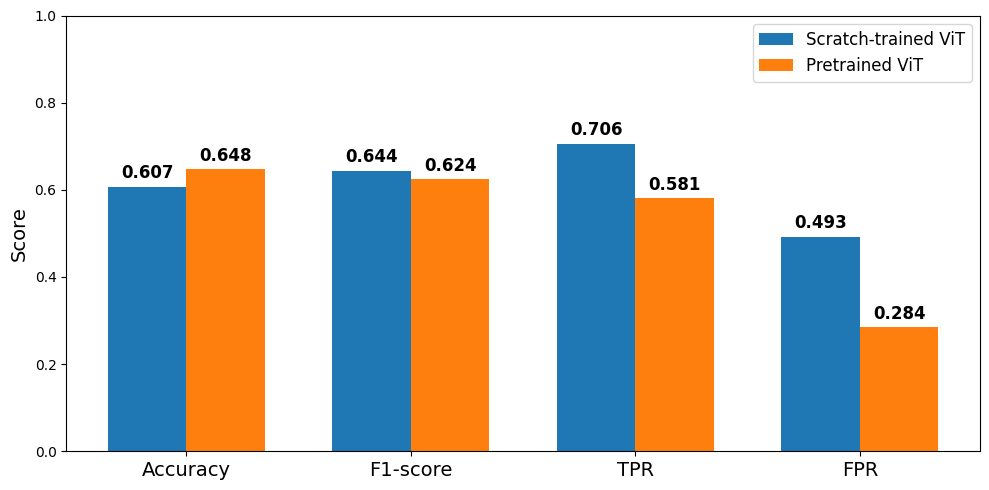

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Combine results
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-score', 'TPR', 'FPR'],
    'Scratch': calculate_performance(scratch_df).values[0],
    'Pretrained': calculate_performance(pretrained_df).values[0]
})

# Plot
x = np.arange(len(comparison_df['Metric']))
width = 0.35

fig, ax = plt.subplots(figsize=(10,5))

bars1 = ax.bar(x - width/2, comparison_df['Scratch'], width, label='Scratch-trained ViT')
bars2 = ax.bar(x + width/2, comparison_df['Pretrained'], width, label='Pretrained ViT')


# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

for bar in bars2:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )


ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Metric'], fontsize=14)

ax.set_ylabel('Score', fontsize=14)
ax.legend(fontsize=12)

plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("model_performance.pdf")
plt.show()

### Bias Evaluation metrics

- Accuracy
- Equal opportunity difference (EOD)
- Average odds difference (AOD)

In [8]:
scratch_df1 = calculate_bias_metrics(scratch_df)
pretrained_df1 = calculate_bias_metrics(pretrained_df)

In [10]:
def calculate_fairness_metrics(df, category, group1_label, group2_label):
    # Extract values
    cat_df = df[df['Category'] == category]
    g1 = cat_df[cat_df['Group'] == group1_label].iloc[0]
    g2 = cat_df[cat_df['Group'] == group2_label].iloc[0]
    
    tpr_diff = g1['TPR'] - g2['TPR']
    fpr_diff = g1['FPR'] - g2['FPR']
    
    # Equalized Odds Difference
    eod = tpr_diff
    
    # Average Odds Difference
    aod = 0.5 * (fpr_diff + tpr_diff)

    ap = g1['Accuracy'] - g2['Accuracy']
    
    return {
        "Groups": f"{group1_label} vs {group2_label}",
        "TPR_Diff": round(tpr_diff, 4),
        "FPR_Diff": round(fpr_diff, 4),
        "EOD": round(eod, 4),
        "AOD": round(aod, 4),
        "AP": round(ap, 4)
    }

In [11]:
res_gender_scratch = calculate_fairness_metrics(scratch_df1, "By Gender", "Female", "Male")
res_gender_pretrained = calculate_fairness_metrics(pretrained_df1, "By Gender", "Female", "Male")
res_view_scratch = calculate_fairness_metrics(scratch_df1, "By View", "AP", "PA")
res_view_pretrained = calculate_fairness_metrics(pretrained_df1, "By View", "AP", "PA")
female_view_scratch = calculate_fairness_metrics(scratch_df1, "Specific", "Female | AP", "Female | PA")
female_view_pretrained = calculate_fairness_metrics(pretrained_df1, "Specific", "Female | AP", "Female | PA")
male_view_scratch = calculate_fairness_metrics(scratch_df1, "Specific", "Male | AP", "Male | PA")
male_view_pretrained = calculate_fairness_metrics(pretrained_df1, "Specific", "Male | AP", "Male | PA")

# Combine into a structured list
summary_data = [
    {"Model": "Scratch", "Category": "Gender", **res_gender_scratch},
    {"Model": "Pretrained", "Category": "Gender", **res_gender_pretrained},
    {"Model": "Scratch", "Category": "View", **res_view_scratch},
    {"Model": "Pretrained", "Category": "View", **res_view_pretrained},
    {"Model": "Scratch", "Category": "Female", **female_view_scratch},
    {"Model": "Pretrained", "Category": "Female", **female_view_pretrained},
    {"Model": "Scratch", "Category": "Male", **male_view_scratch},
    {"Model": "Pretrained", "Category": "Male", **male_view_pretrained},
]

# Create the final DataFrame
final_results_df = pd.DataFrame(summary_data)

# Reorder columns for better readability
final_results_df = final_results_df[['Model', 'Category', 'Groups', 'EOD', 'AOD', 'TPR_Diff', 'FPR_Diff', 'AP']]

display(final_results_df)

,Model,Category,Groups,EOD,AOD,TPR_Diff,FPR_Diff,AP
0,Scratch,Gender,Female vs Male,0.025,0.0435,0.025,0.062,-0.015
1,Pretrained,Gender,Female vs Male,-0.055,-0.0300,-0.055,-0.005,-0.027
2,Scratch,View,AP vs PA,0.018,-0.0110,0.018,-0.040,0.029
3,Pretrained,View,AP vs PA,-0.060,-0.0410,-0.060,-0.022,-0.018
4,Scratch,Female,Female | AP vs Female | PA,0.037,0.0160,0.037,-0.005,0.025
5,Pretrained,Female,Female | AP vs Female | PA,-0.072,-0.0405,-0.072,-0.009,-0.035
6,Scratch,Male,Male | AP vs Male | PA,-0.005,-0.0405,-0.005,-0.076,0.033
7,Pretrained,Male,Male | AP vs Male | PA,-0.041,-0.0385,-0.041,-0.036,0.000


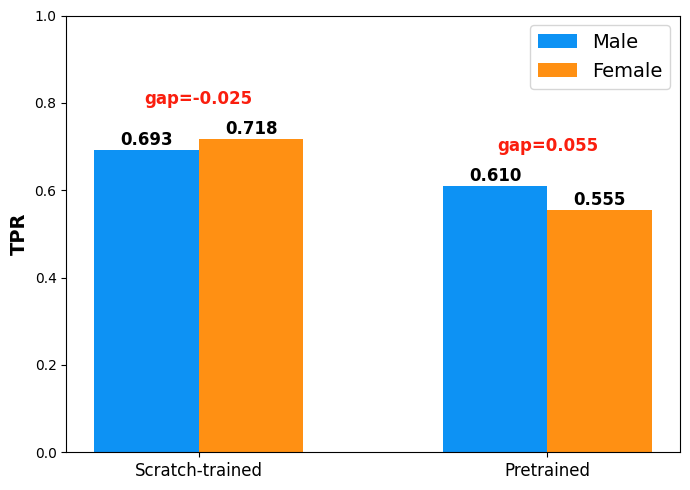

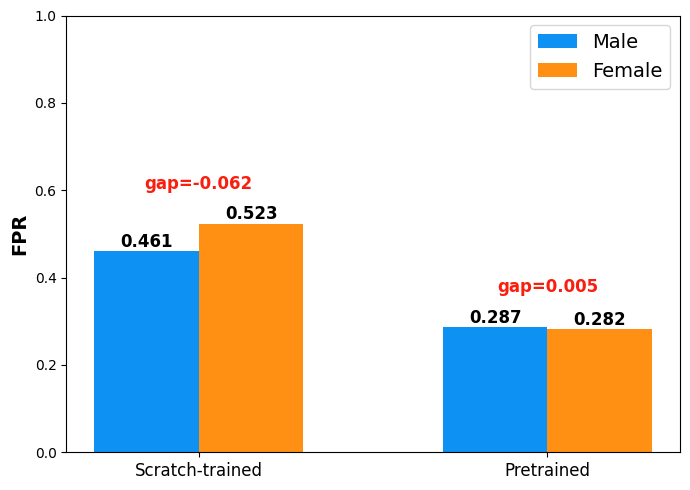

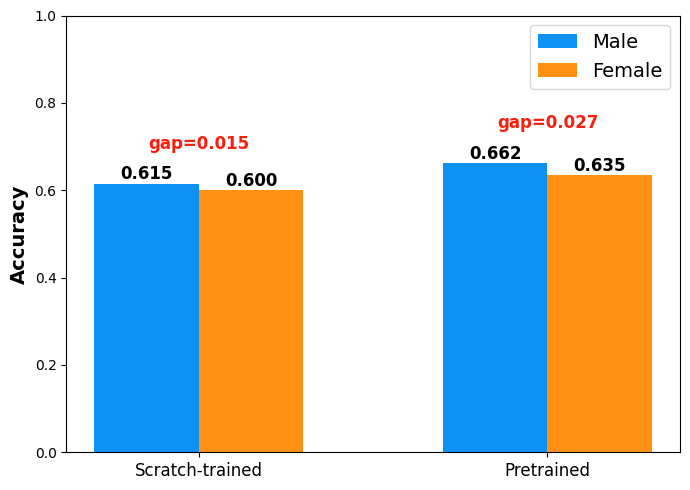

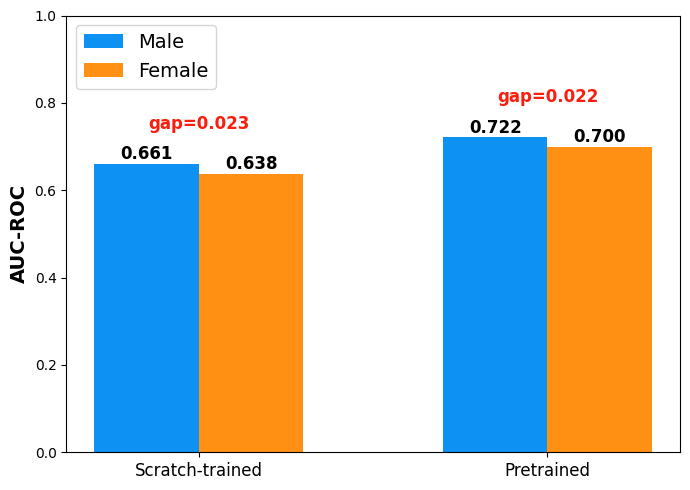

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Colors
# -----------------------------
colors = ['#0D92F4', '#FF9013', '#FA1E0E']

#colors = ['#55AD9B', '#FD7979', '#FA1E0E']
male_color = colors[0]
female_color = colors[1]
gap_color = colors[2]

# -----------------------------
# Filter data
# -----------------------------
gender = result_df[result_df['Category'] == "By Gender"]

scr = gender[gender['Model'] == 'Scratch'].set_index("Group")
pre = gender[gender['Model'] == 'Pretrained'].set_index("Group")

labels = ["Male", "Female"]
metrics = ["TPR", "FPR", "Accuracy", "AUC-ROC"]

x = np.arange(2)
width = 0.3

for metric in metrics:

    scr_vals = scr.loc[labels, metric].values
    pre_vals = pre.loc[labels, metric].values

    fig, ax = plt.subplots(figsize=(7, 5))

    # -----------------------------
    # Bars with gender colors
    # -----------------------------
    bars1 = ax.bar(x - width/2, [scr_vals[0], pre_vals[0]],
                   width, label="Male", color=male_color)

    bars2 = ax.bar(x + width/2, [scr_vals[1], pre_vals[1]],
                   width, label="Female", color=female_color)

    # -----------------------------
    # Styling
    # -----------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(["Scratch-trained", "Pretrained"], fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_ylabel(metric,fontsize=14,fontweight='bold')
    ax.legend(fontsize=14)

    # -----------------------------
    # Value labels
    # -----------------------------
    def add_labels(bars):
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, h + 0.01,
                    f"{h:.3f}", ha='center', fontsize=12, fontweight='bold')

    add_labels(bars1)
    add_labels(bars2)

    # -----------------------------
    # Gap annotation (Male - Female)
    # -----------------------------
    gap_scr = scr_vals[0] - scr_vals[1]
    gap_pre = pre_vals[0] - pre_vals[1]

    ax.text(0, max(scr_vals) + 0.08, f"gap={gap_scr:.3f}",
            ha='center', fontweight='bold', color=gap_color, fontsize=12)

    ax.text(1, max(pre_vals) + 0.08, f"gap={gap_pre:.3f}",
            ha='center', fontweight='bold', color=gap_color, fontsize=12)

    plt.tight_layout()
    plt.savefig(f'{metric}_gender.pdf')
    plt.show()

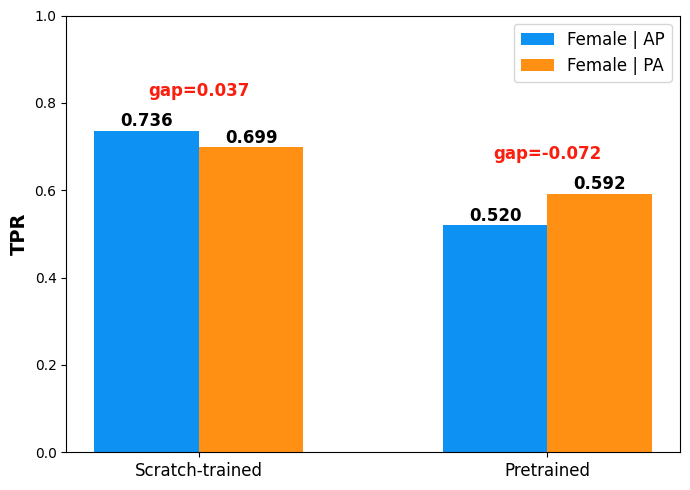

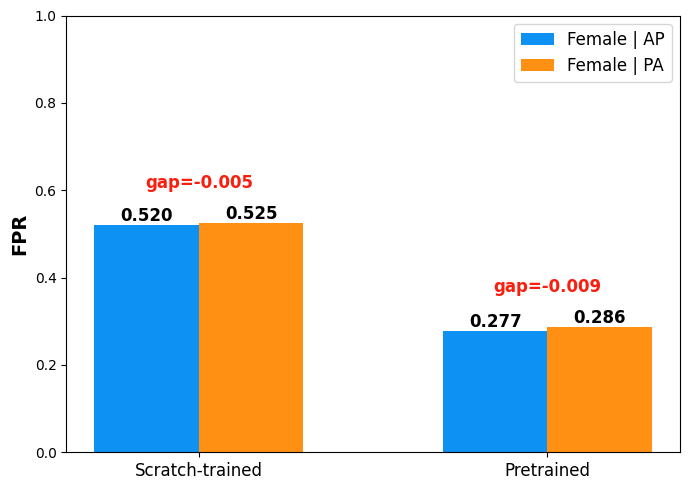

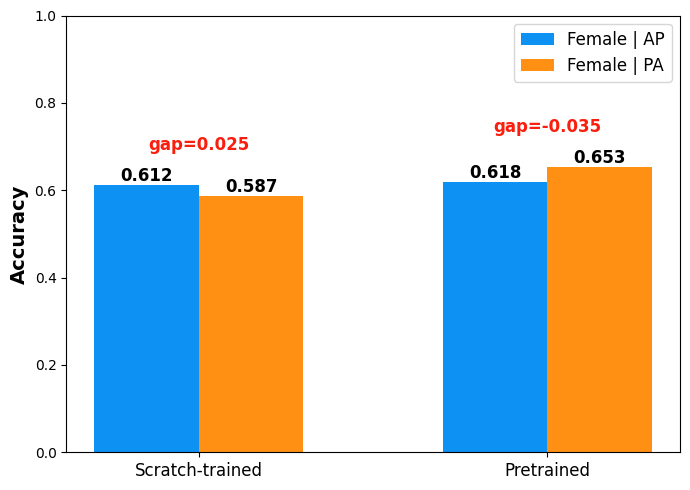

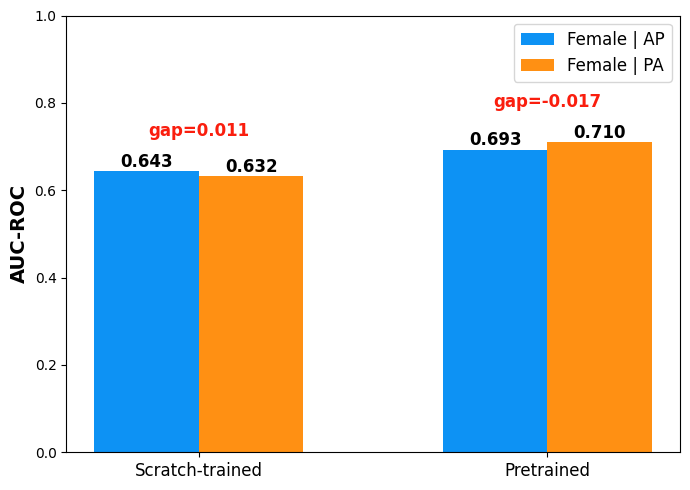

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Colors
# -----------------------------
colors = ['#0D92F4', '#FF9013', '#FA1E0E']
ap_color = colors[0]
pa_color = colors[1]
gap_color = colors[2]

# -----------------------------
# Filter data
# -----------------------------
view = result_df[result_df['Category'] == "Specific"]

scr = view[view['Model'] == 'Scratch'].set_index("Group")
pre = view[view['Model'] == 'Pretrained'].set_index("Group")

labels = ["Female | AP", "Female | PA"]
metrics = ["TPR", "FPR", "Accuracy", "AUC-ROC"]

x = np.arange(2)
width = 0.3

for metric in metrics:

    scr_vals = scr.loc[labels, metric].values
    pre_vals = pre.loc[labels, metric].values

    fig, ax = plt.subplots(figsize=(7, 5))

    # -----------------------------
    # Bars with gender colors
    # -----------------------------
    bars1 = ax.bar(x - width/2, [scr_vals[0], pre_vals[0]],
                   width, label="Female | AP", color=ap_color)

    bars2 = ax.bar(x + width/2, [scr_vals[1], pre_vals[1]],
                   width, label="Female | PA", color=pa_color)

    # -----------------------------
    # Styling
    # -----------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(["Scratch-trained", "Pretrained"], fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_ylabel(metric,fontsize=14,fontweight='bold')
    ax.legend(fontsize=12)

    # -----------------------------
    # Value labels
    # -----------------------------
    def add_labels(bars):
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, h + 0.01,
                    f"{h:.3f}", ha='center', fontsize=12, fontweight='bold')

    add_labels(bars1)
    add_labels(bars2)

    # -----------------------------
    # Gap annotation (Male - Female)
    # -----------------------------
    gap_scr = scr_vals[0] - scr_vals[1]
    gap_pre = pre_vals[0] - pre_vals[1]

    ax.text(0, max(scr_vals) + 0.08, f"gap={gap_scr:.3f}",
            ha='center', fontweight='bold', color=gap_color, fontsize=12)

    ax.text(1, max(pre_vals) + 0.08, f"gap={gap_pre:.3f}",
            ha='center', fontweight='bold', color=gap_color, fontsize=12)

    plt.tight_layout()
    plt.savefig(f'{metric}_femaleview.pdf')
    plt.show()

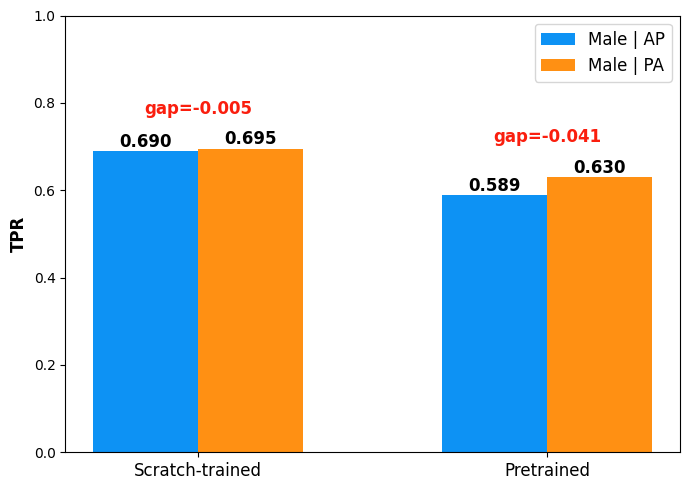

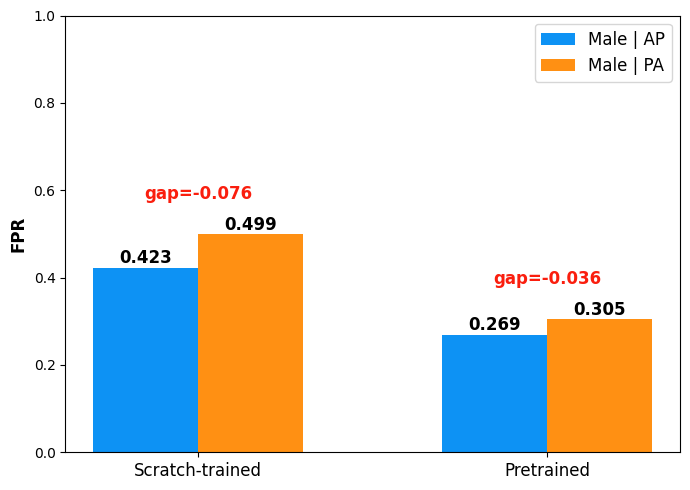

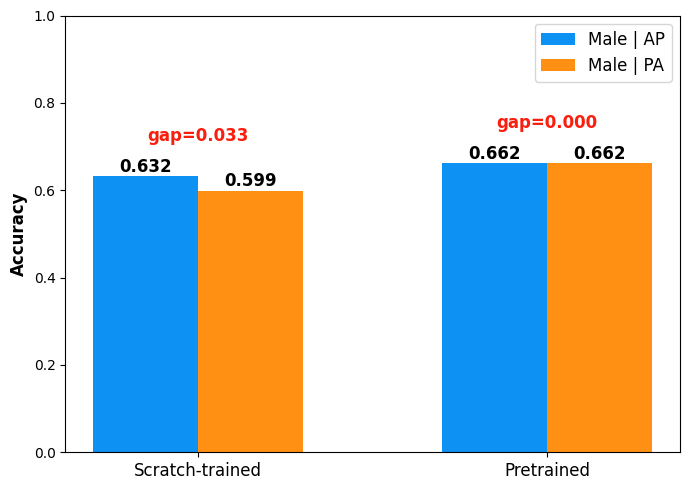

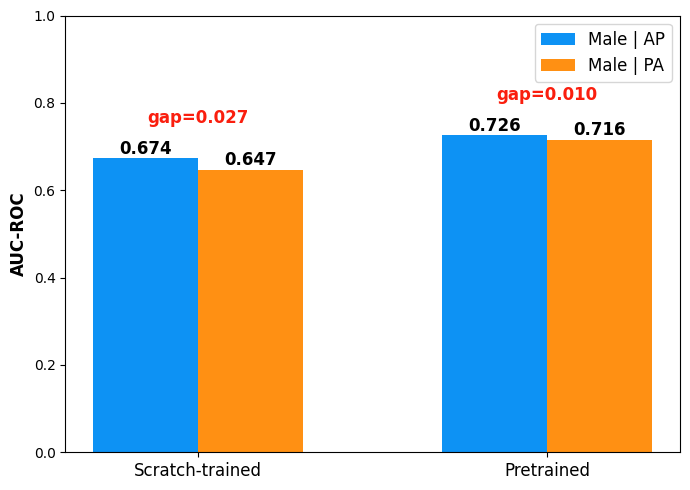

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Colors
# -----------------------------
colors = ['#0D92F4', '#FF9013', '#FA1E0E']
ap_color = colors[0]
pa_color = colors[1]
gap_color = colors[2]

# -----------------------------
# Filter data
# -----------------------------
view = result_df[result_df['Category'] == "Specific"]

scr = view[view['Model'] == 'Scratch'].set_index("Group")
pre = view[view['Model'] == 'Pretrained'].set_index("Group")

labels = ["Male | AP", "Male | PA"]
metrics = ["TPR", "FPR", "Accuracy", "AUC-ROC"]

x = np.arange(2)
width = 0.3

for metric in metrics:

    scr_vals = scr.loc[labels, metric].values
    pre_vals = pre.loc[labels, metric].values

    fig, ax = plt.subplots(figsize=(7, 5))

    # -----------------------------
    # Bars with gender colors
    # -----------------------------
    bars1 = ax.bar(x - width/2, [scr_vals[0], pre_vals[0]],
                   width, label="Male | AP", color=ap_color)

    bars2 = ax.bar(x + width/2, [scr_vals[1], pre_vals[1]],
                   width, label="Male | PA", color=pa_color)

    # -----------------------------
    # Styling
    # -----------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(["Scratch-trained", "Pretrained"], fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_ylabel(metric,fontsize=12,fontweight='bold')
    ax.legend(fontsize=12)

    # -----------------------------
    # Value labels
    # -----------------------------
    def add_labels(bars):
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, h + 0.01,
                    f"{h:.3f}", ha='center', fontsize=12, fontweight='bold')

    add_labels(bars1)
    add_labels(bars2)

    # -----------------------------
    # Gap annotation (Male - Female)
    # -----------------------------
    gap_scr = scr_vals[0] - scr_vals[1]
    gap_pre = pre_vals[0] - pre_vals[1]

    ax.text(0, max(scr_vals) + 0.08, f"gap={gap_scr:.3f}",
            ha='center', fontweight='bold', color=gap_color, fontsize=12)

    ax.text(1, max(pre_vals) + 0.08, f"gap={gap_pre:.3f}",
            ha='center', fontweight='bold', color=gap_color, fontsize=12)

    plt.tight_layout()
    plt.savefig(f'{metric}_maleview.pdf')
    plt.show()

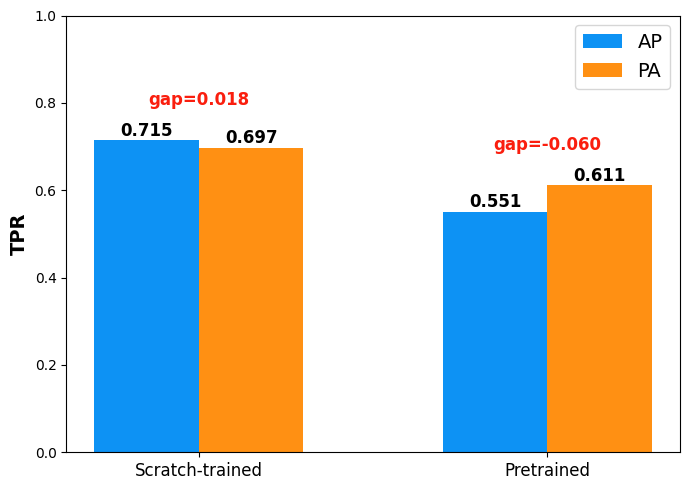

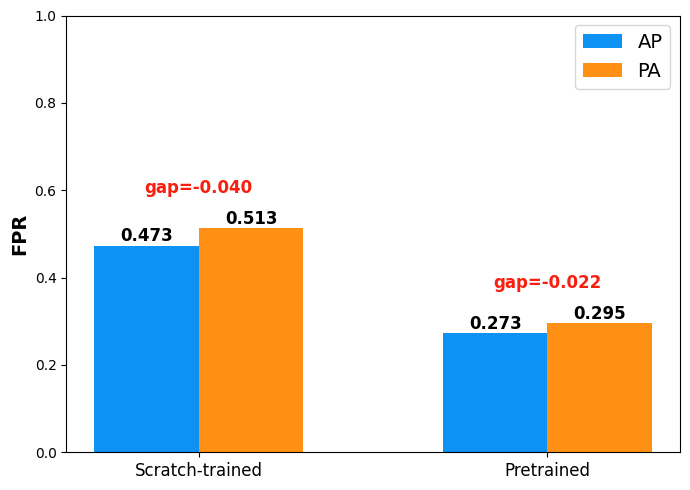

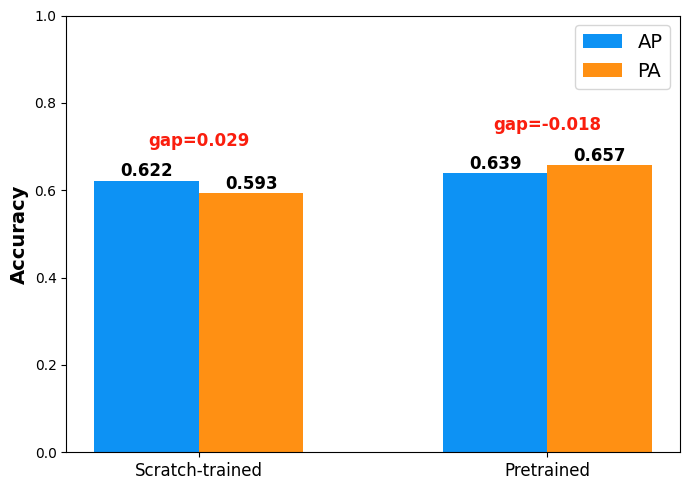

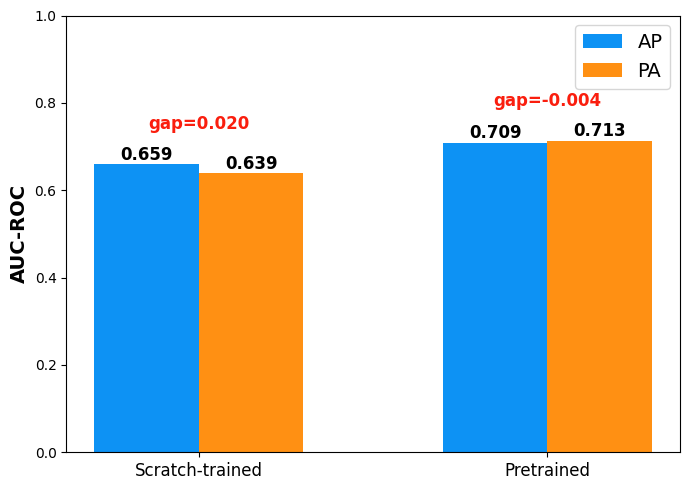

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Colors
# -----------------------------
colors = ['#0D92F4', '#FF9013', '#FA1E0E']

#colors = ['#55AD9B', '#FD7979', '#FA1E0E']
male_color = colors[0]
female_color = colors[1]
gap_color = colors[2]

# -----------------------------
# Filter data
# -----------------------------
gender = result_df[result_df['Category'] == "By View"]

scr = gender[gender['Model'] == 'Scratch'].set_index("Group")
pre = gender[gender['Model'] == 'Pretrained'].set_index("Group")

labels = ["AP", "PA"]
metrics = ["TPR", "FPR", "Accuracy", "AUC-ROC"]

x = np.arange(2)
width = 0.3

for metric in metrics:

    scr_vals = scr.loc[labels, metric].values
    pre_vals = pre.loc[labels, metric].values

    fig, ax = plt.subplots(figsize=(7, 5))

    # -----------------------------
    # Bars with gender colors
    # -----------------------------
    bars1 = ax.bar(x - width/2, [scr_vals[0], pre_vals[0]],
                   width, label="AP", color=male_color)

    bars2 = ax.bar(x + width/2, [scr_vals[1], pre_vals[1]],
                   width, label="PA", color=female_color)

    # -----------------------------
    # Styling
    # -----------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(["Scratch-trained", "Pretrained"], fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_ylabel(metric,fontsize=14,fontweight='bold')
    ax.legend(fontsize=14)

    # -----------------------------
    # Value labels
    # -----------------------------
    def add_labels(bars):
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width()/2, h + 0.01,
                    f"{h:.3f}", ha='center', fontsize=12, fontweight='bold')

    add_labels(bars1)
    add_labels(bars2)

    # -----------------------------
    # Gap annotation (Male - Female)
    # -----------------------------
    gap_scr = scr_vals[0] - scr_vals[1]
    gap_pre = pre_vals[0] - pre_vals[1]

    ax.text(0, max(scr_vals) + 0.08, f"gap={gap_scr:.3f}",
            ha='center', fontweight='bold', color=gap_color, fontsize=12)

    ax.text(1, max(pre_vals) + 0.08, f"gap={gap_pre:.3f}",
            ha='center', fontweight='bold', color=gap_color, fontsize=12)

    plt.tight_layout()
    plt.savefig(f'{metric}_view.pdf')
    plt.show()